# SI Code 2a | Sampler-budget and proxy-definition sensitivity tests

Companion to `SI_code2_TEXAS_analysis.ipynb`. It answers two questions that the
main analysis notebook takes as settled:

**Part 1 — How many HMC iterations does the calibration actually need?**
The coretop layer is the expensive fit (N = 1513 sites, plus 2 × 1513 latent
variables in the EIV model), and it is re-run every time the training
compilation grows. We sweep warmup ∈ {100, 200, 300, 400, 500} × sampling ∈
{1, 1.5, 2, 2.5, 3} × warmup and show where R̂, ESS and the posterior means
themselves stop moving, so the production budget can be set from evidence
rather than from CmdStan's 1000/1000 default.

**Part 2 — Does the crenarchaeol ring assignment change the calibration?**
The Ring Index requires a ring count for crenarchaeol and its regioisomer,
which is a convention, not a measurement. We refit the entire two-stage
calibration under all three conventions in circulation:

| notebook label | column | crenarchaeol counted as | provenance |
|---|---|---|---|
| **SRI03** | `scaledRI_cren3` | 3 rings | this study (production calibration) |
| **SRI04** | `scaledRI` | 4 rings | RI₀₋₄ of Zhang et al. (2016) |
| **SRI05** | `scaledRI_cren5` | 5 rings | cyclopentane + cyclohexane counted |

Scaled RI is `RI / cren_rings`, so all three land on a comparable [0, 1] scale
and the comparison is about curve shape and skill, not units.

---

### Running this notebook

Everything is **cache-aware**: completed cases are read back from
`data/revision1/groupA/param_sensitivity/` and skipped. Delete that directory,
or set `FORCE_RERUN = True`, to resample.

| stage | iterations | wall time (8-core Linux box, 4 chains) |
|---|---|---|
| Part 1, univariate grid + references | 29,500 | ≈ 7 min |
| Part 1, EIV grid + references | 29,500 | ≈ 65 min |
| Part 2, SRI04 + SRI05 (SRI03 reuses the `SI_code2` posteriors) | — | ≈ 10 min |
| **total, cold cache** | | **≈ 1.4 h** |
| `QUICK = True` smoke run of both parts | | ≈ 12 min |

Measured 2026-08-12: 0.013 s/iteration for the univariate coretop model and
0.132 s/iteration for the EIV multivariate model, both at N = 1513 with 4
parallel chains.

> **Do not run a second Stan job while this notebook is sampling.** Every TEXAS
> process shares one compiled-binary directory (`~/.texas/stan_cache`) and this
> notebook already saturates 4 cores. Running two concurrently roughly triples
> the per-iteration cost and can kill the kernel outright, with no Python
> traceback — the progress bar simply turns red. Nothing is lost when that
> happens: `run_grid()` writes after every cell and skips what is already in
> `mcmc_budget_grid.csv`, so re-running the cell resumes where it stopped.

`QUICK = True` shrinks the grid and the iteration counts. It exercises every
code path and produces every figure, but the numbers are **not** publishable —
set it back to `False` for the real run.

# Environment

In [1]:
!python --version
import os
import warnings

# suppress warnings
warnings.filterwarnings('ignore')

Python 3.13.5


In [2]:
import json
import time
import math
from dataclasses import dataclass
from pathlib import Path

import numpy as np
import pandas as pd
import xarray as xr

np.random.seed(42)   # reproducibility; Stan seeds are set explicitly below
xr.set_options(file_cache_maxsize=10)

import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.colors import TwoSlopeNorm

# This notebook deliberately uses plain matplotlib (no ultraplot/arviz) so it
# runs in a bare `texas-env` without extra installs.
mpl.rcParams.update({
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
    'figure.dpi': 110,
    'savefig.dpi': 300,
    'axes.grid': False,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 10,
})

from tqdm.auto import tqdm

In [3]:
from cmdstanpy import set_cmdstan_path, cmdstan_path
from TEXAS.utils.paths import CMDSTAN_DIR

set_cmdstan_path(str(CMDSTAN_DIR))
print("Set CMDSTAN ->", cmdstan_path())

import TEXAS
from TEXAS.stan.compiler import StanCompiler
from TEXAS.stan.sampler import StanSampler, get_posterior, auto_detect_predictors
from TEXAS.stan.io import load_posterior, save_posterior
from TEXAS.data import build_fwd_data
from TEXAS.diagnostics import summarize_sampler_diagnostics
from TEXAS.ensemble import generate_ensemble_auto
from TEXAS.models.multivariate import (
    generalized_logistic_fixed_upper_multivariate,
    inverse_generalized_logistic_fixed_upper_multivariate,
)

print("TEXAS", TEXAS.__version__, "->", TEXAS.__file__)

Set CMDSTAN -> /home/rrattan/.cmdstan/cmdstan-2.36.0
TEXAS 0.2.6 -> /home/rrattan/Documents/GitHub/TEXAS/src/TEXAS/__init__.py


# Paths

In [4]:
IN_DOCKER = Path("/home/micromamba/app").exists()


def _find_repo_root(start=None):
    '''Walk up from the notebook until pyproject.toml appears.'''
    if IN_DOCKER:
        return Path("/home/micromamba/app")
    p = (start or Path.cwd()).resolve()
    for cand in (p, *p.parents):
        if (cand / "pyproject.toml").exists() and (cand / "src" / "TEXAS").exists():
            return cand
    raise FileNotFoundError(
        f"Could not locate the TEXAS repo root above {p}. "
        "Set local_github_path by hand."
    )


local_github_path = _find_repo_root()

RESULTS_DIR = local_github_path / "data" / "revision1" / "groupA" / "param_sensitivity"
FIG_DIR     = local_github_path / "figures" / "manuscript" / "revision1"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

print("repo    :", local_github_path)
print("results :", RESULTS_DIR)
print("figures :", FIG_DIR)


def savefig(fig, stem):
    '''Write both a PDF (for the SI) and a PNG (for quick viewing).'''
    for ext in ("pdf", "png"):
        fig.savefig(FIG_DIR / f"{stem}.{ext}", bbox_inches="tight",
                    facecolor="white")
    print("saved ->", FIG_DIR / f"{stem}.[pdf|png]")

repo    : /home/rrattan/Documents/GitHub/TEXAS
results : /home/rrattan/Documents/GitHub/TEXAS/data/revision1/groupA/param_sensitivity
figures : /home/rrattan/Documents/GitHub/TEXAS/figures/manuscript/revision1


# Configuration

`QUICK` is the only switch you normally touch. Everything downstream — grid
size, iteration counts, which models are swept — derives from it.

In [5]:
QUICK       = False    # True -> fast smoke run; numbers are NOT publishable
FORCE_RERUN = False    # True -> ignore cached results and resample everything

CHAINS = 4             # held fixed: R-hat is only comparable at fixed chain count
SEED   = 42

# ── Part 1: the budget grid ────────────────────────────────────────────────
WARMUPS     = [100, 200, 300, 400, 500]
MULTIPLIERS = [1.0, 1.5, 2.0, 2.5, 3.0]     # iter_sampling = multiplier x warmup

# The reference ("gold standard") run every grid cell is compared against.
REF_WARMUP, REF_SAMPLING = 1000, 4000

# CmdStan's own default, shown on the figures as the incumbent production budget.
DEFAULT_WARMUP, DEFAULT_SAMPLING = 1000, 1000

# Models swept. The univariate coretop fit is cheap and thermal-only; the EIV
# multivariate fit is the production bottleneck and the one the recommendation
# is actually about.
# boundedT is swept as its own model rather than assumed to inherit the
# parent's budget. The two place the predictors differently -- the parent adds
# beta * G23 to the response, outside the logistic, while boundedT adds
# gamma * G23 to the inflection point, inside it. That makes gamma and t0
# near-degenerate whenever G23 has limited spread, and both gamma parameters
# are hard-bounded at zero with much wider priors than the betas. It is the
# harder geometry, so it is the one likely to set the binding budget.
GRID_MODELS = [
    ("univ",  "gen_logi_fixed_hier_crtp_univ_priorApprox"),
    ("eiv",   "gen_logi_fixed_hier_crtp_multiv_priorApprox_eiv"),
    ("bnd",   "gen_logi_fixed_hier_crtp_multiv_priorApprox_eiv_boundedT"),
]

# ── Part 2: the proxy definitions ──────────────────────────────────────────
# label -> (column in the compilation, crenarchaeol ring count, plot colour)
PROXIES = {
    "SRI03": dict(column="scaledRI_cren3", cren_rings=3, color="#2e6f9e"),
    "SRI04": dict(column="scaledRI",       cren_rings=4, color="#c1832f"),
    "SRI05": dict(column="scaledRI_cren5", cren_rings=5, color="#8d5a9b"),
}
PRODUCTION_PROXY = "SRI03"

TEMPTYPE   = "SST"
NO3_CUTOFF = 1.0

# Analytical (measurement) SE of the *scaled* Ring Index fed to the EIV model.
#   "scaled_constant" -> 0.03 on every scaled proxy, i.e. the Schouten et al.
#                        (2013) reproducibility applied in scaled units.
#   "ri_constant"     -> 0.03 x 3 / cren_rings, i.e. holding the SE constant in
#                        raw RI units instead.
# The three conventions differ by <7% in scaled spread, so the choice is
# immaterial to the conclusion; it is exposed because it is a real assumption.
SD_PROXYOBS_MODE = "scaled_constant"
SD_PROXYOBS_BASE = 0.03

if QUICK:
    WARMUPS     = [100, 300]
    MULTIPLIERS = [1.0, 2.0]
    REF_WARMUP, REF_SAMPLING = 400, 800
    PART2_WARMUP, PART2_SAMPLING = 300, 300
else:
    PART2_WARMUP, PART2_SAMPLING = DEFAULT_WARMUP, DEFAULT_SAMPLING

GRID = [(w, int(round(w * m)), m) for w in WARMUPS for m in MULTIPLIERS]

print(f"QUICK={QUICK}  FORCE_RERUN={FORCE_RERUN}")
print(f"Part 1: {len(GRID)} budget cells x {len(GRID_MODELS)} models "
      f"= {len(GRID) * len(GRID_MODELS)} fits (+{len(GRID_MODELS)} reference runs)")
print(f"Part 2: {len(PROXIES)} proxies x 3 stages = {3 * len(PROXIES)} fits "
      f"at {PART2_WARMUP}/{PART2_SAMPLING}")

QUICK=False  FORCE_RERUN=False
Part 1: 25 budget cells x 2 models = 50 fits (+2 reference runs)
Part 2: 3 proxies x 3 stages = 9 fits at 1000/1000


# Training data

The same gridded, screened compilation the production calibration uses. Nothing
is re-screened here — both parts must see exactly the data the main notebook
sees, or the sensitivity test measures the wrong thing.

In [6]:
fpath = local_github_path / "data" / "spreadsheets"
fname = "ds_gridded_screened_global_compilation_finalized.csv"

gridded_combined_df = pd.read_csv(fpath / fname, low_memory=False)

PROXY_COLS = [v["column"] for v in PROXIES.values()]
missing = [c for c in PROXY_COLS if c not in gridded_combined_df.columns]
if missing:
    raise KeyError(f"proxy columns absent from the compilation: {missing}")

coretop_df = (gridded_combined_df[gridded_combined_df["datatype"] == "coretop"]
              .dropna(subset=["no3_sf2tc_avg", "SST"])
              .reset_index(drop=True))

print(f"compilation : {len(gridded_combined_df)} rows")
print(gridded_combined_df.groupby("datatype")[PROXY_COLS + ["SST"]].count())
print(f"\ncoretop (NO3 + SST complete): {len(coretop_df)}")

compilation : 1576 rows
          scaledRI_cren3  scaledRI  scaledRI_cren5   SST
datatype                                                
coretop             1513      1513            1513  1513
culture               55        55              55    55
mesocosm               8         8               8     8

coretop (NO3 + SST complete): 1513


In [7]:
# Sanity check on the ring-count convention: scaled RI x cren_rings must
# reproduce the unscaled Ring Index column it was derived from.
_ri_pairs = {"scaledRI_cren3": "ringIndex_cren3",
             "scaledRI":       "ringIndex",
             "scaledRI_cren5": "ringIndex_cren5"}
for label, cfg in PROXIES.items():
    col = cfg["column"]
    ri  = _ri_pairs[col]
    err = (gridded_combined_df[col] * cfg["cren_rings"]
           - gridded_combined_df[ri]).abs().max()
    print(f"{label:6s} {col:16s} x {cfg['cren_rings']}  vs {ri:16s} "
          f"max|diff| = {err:.2e}")

SRI03  scaledRI_cren3   x 3  vs ringIndex_cren3  max|diff| = 1.00e-09
SRI04  scaledRI         x 4  vs ringIndex        max|diff| = 2.00e-09
SRI05  scaledRI_cren5   x 5  vs ringIndex_cren5  max|diff| = 2.00e-09


---
# Part 1 | How many HMC iterations does the coretop fit need?

### What is measured, and why the low-level sampler is used here

Three models are swept: the univariate coretop fit, the parent additive-EIV
multivariate fit, and the bounded-T variant. The budget is **not** assumed to
transfer between them — R̂ at a fixed budget already differs measurably between
the univariate and parent fits, and bounded-T has the hardest geometry of the
three, so each gets its own grid and its own recommendation.

Part 1 calls `StanCompiler` / `CmdStanModel.sample` directly rather than
`get_posterior()`. The reason is diagnostic resolution: `get_posterior()`
attaches only the *aggregate* diagnostics (max R̂, min ESS) to the returned
dataset, and this test needs CmdStan's **per-parameter** `R_hat` / `ESS_bulk` /
`ESS_tail` table to show *which* parameter is the last to converge. The data
dict is passed through `auto_detect_predictors()` first, exactly as
`get_posterior()` does, so the model sees identical inputs.

Four families of metric are recorded per budget cell:

| family | metric | why |
|---|---|---|
| **convergence** | max R̂ over all parameters, count of R̂ > 1.01 | the headline question |
| **efficiency** | min/median ESS_bulk, ESS_tail, **ESS_bulk per second** | a cheap run that mixes badly is not cheap |
| **validity** | % divergent transitions, % at max treedepth, min E-BFMI | R̂ can look fine while the geometry is broken |
| **accuracy** | ‖posterior mean − reference mean‖ / reference SD | R̂ is a necessary, not sufficient, condition |

The last one is the check that matters for a calibration: a budget is only
adequate if the posterior it produces is indistinguishable from a long
reference run, not merely internally consistent.

In [8]:
# Both naming conventions are listed because the accuracy check below only
# covers parameters it can find. Omitting the gamma_* pair would silently
# exclude boundedT's two hardest-to-identify parameters from exactly the test
# that exists to catch them. Missing names are skipped per model, so listing
# both is safe.
CORE_PARAMS = ["t0_crtp", "k_crtp", "b_crtp", "v_crtp", "sigma_proxyObs_crtp",
               "beta_G23_crtp", "beta_NO3_crtp",      # parent (additive EIV)
               "gamma_G23_crtp", "gamma_NO3_crtp"]    # boundedT

_compiler = StanCompiler()


def build_part1_data(model_key, proxy_col=None):
    '''Stan data dict for the Part 1 grid, for one of the two swept models.'''
    proxy_col = proxy_col or PROXIES[PRODUCTION_PROXY]["column"]
    culmeso_post = load_posterior(f"gen_logi_fixed_culmeso_cultureT_{proxy_col}")

    if model_key == "univ":
        reg = coretop_df[["SST", proxy_col]].dropna()
        return build_fwd_data(
            t_crtp=reg["SST"].values,
            proxy_crtp=reg[proxy_col].values,
            culmeso_posterior=culmeso_post,
        ), len(reg)

    # The two EIV models declare byte-identical Stan data blocks (16 keys), so
    # one builder serves both.
    if model_key in ("eiv", "bnd"):
        reg = coretop_df[["SST", proxy_col, "gdgt23ratio", "gdgt23ratio_se",
                          "no3_sf2tc_avg", "thermoNO3_se"]].dropna()
        thermal_post = load_posterior(
            f"gen_logi_fixed_hier_crtp_univ_priorApprox_{TEMPTYPE}_{proxy_col}")
        R2_thermal = float(thermal_post["R2_full"].mean())
        return build_fwd_data(
            t_crtp              = reg["SST"].values,
            proxy_crtp          = reg[proxy_col].values,
            gdgt23ratio_crtp    = reg["gdgt23ratio"].values,
            sd_gdgt23ratio_crtp = reg["gdgt23ratio_se"].values,
            no3_crtp            = reg["no3_sf2tc_avg"].values,
            sd_no3_crtp         = reg["thermoNO3_se"].values,
            R2_thermal          = R2_thermal,
            culmeso_posterior   = culmeso_post,
            no3_cutoff          = NO3_CUTOFF,
        ), len(reg)

    raise ValueError(
        f"unknown model key {model_key!r}; expected one of "
        f"{sorted({k for k, _ in GRID_MODELS})}"
    )

In [9]:
def run_budget_case(model_key, stan_file, data, iter_warmup, iter_sampling,
                    seed=SEED, chains=CHAINS):
    '''
    Sample once at a given budget and return (metrics dict, per-parameter table).

    Wall time is measured around `model.sample` only — compilation is excluded,
    since it happens once per session and is not part of the budget question.
    '''
    model = _compiler.get_model(stan_file)          # cached after the first call

    t_start = time.time()
    fit = model.sample(
        data=data,
        chains=chains,
        parallel_chains=chains,
        iter_warmup=iter_warmup,
        iter_sampling=iter_sampling,
        seed=seed,
        show_progress=False,
        show_console=False,
    )
    wall = time.time() - t_start

    summary = fit.summary()                          # CmdStan's own R_hat / ESS
    diag    = summarize_sampler_diagnostics(fit)

    # lp__ is not a model parameter; keep it out of the "did the parameters
    # converge" statistics but report it separately, since it is the most
    # sensitive single indicator of a badly adapted warmup.
    params = summary.drop(index=[i for i in summary.index if i == "lp__"],
                          errors="ignore")

    row = {
        "model": model_key,
        "stan_file": stan_file,
        "iter_warmup": iter_warmup,
        "iter_sampling": iter_sampling,
        "multiplier": iter_sampling / iter_warmup,
        "chains": chains,
        "total_draws": chains * iter_sampling,
        "total_iters": chains * (iter_warmup + iter_sampling),
        "wall_sec": wall,
        "max_rhat": float(params["R_hat"].max()),
        "n_rhat_gt_101": int((params["R_hat"] > 1.01).sum()),
        "n_rhat_gt_105": int((params["R_hat"] > 1.05).sum()),
        "worst_rhat_param": str(params["R_hat"].idxmax()),
        "lp_rhat": float(summary.loc["lp__", "R_hat"]) if "lp__" in summary.index else np.nan,
        "min_ess_bulk": float(params["ESS_bulk"].min()),
        "median_ess_bulk": float(params["ESS_bulk"].median()),
        "min_ess_tail": float(params["ESS_tail"].min()) if "ESS_tail" in params else np.nan,
        "pct_divergent": diag["stan_diag_pct_divergent"],
        "pct_max_treedepth": diag["stan_diag_pct_max_treedepth"],
        "min_ebfmi": diag["stan_diag_min_ebfmi"],
    }
    row["ess_bulk_per_sec"] = row["min_ess_bulk"] / wall
    row["sec_per_1000_draws"] = 1000 * wall / row["total_draws"]

    # Per-parameter draws for the core scalars -> mean/sd used by the accuracy
    # comparison against the reference run.
    ds = fit.draws_xr()
    par_rows = []
    for p in CORE_PARAMS:
        if p not in ds:
            continue
        v = np.asarray(ds[p].values, dtype=float).ravel()
        par_rows.append({
            "model": model_key, "iter_warmup": iter_warmup,
            "iter_sampling": iter_sampling, "param": p,
            "mean": float(v.mean()), "sd": float(v.std(ddof=1)),
            "q025": float(np.percentile(v, 2.5)),
            "q500": float(np.percentile(v, 50)),
            "q975": float(np.percentile(v, 97.5)),
            "rhat": float(summary.loc[p, "R_hat"]) if p in summary.index else np.nan,
            "ess_bulk": float(summary.loc[p, "ESS_bulk"]) if p in summary.index else np.nan,
        })
    return row, pd.DataFrame(par_rows)

In [10]:
GRID_CSV  = RESULTS_DIR / "mcmc_budget_grid.csv"
PARAM_CSV = RESULTS_DIR / "mcmc_budget_params.csv"

_KEY = ["model", "iter_warmup", "iter_sampling"]


def _load_cached(path):
    if path.exists() and not FORCE_RERUN:
        return pd.read_csv(path)
    return pd.DataFrame()


def _already_done(df, model_key, w, s):
    if df.empty:
        return False
    return bool(((df["model"] == model_key) & (df["iter_warmup"] == w)
                 & (df["iter_sampling"] == s)).any())


def run_grid():
    '''Run every (model, budget) cell not already cached; append as we go.'''
    grid_df  = _load_cached(GRID_CSV)
    param_df = _load_cached(PARAM_CSV)

    # Reference + incumbent-default budgets are run alongside the grid so they
    # appear in the same table with the same metrics.
    extra = [(REF_WARMUP, REF_SAMPLING), (DEFAULT_WARMUP, DEFAULT_SAMPLING)]
    todo = []
    for model_key, stan_file in GRID_MODELS:
        budgets = [(w, s) for w, s, _ in GRID] + extra
        seen = set()
        for w, s in budgets:
            if (w, s) in seen:
                continue
            seen.add((w, s))
            if not _already_done(grid_df, model_key, w, s):
                todo.append((model_key, stan_file, w, s))

    if not todo:
        print("all grid cells cached — nothing to run")
        return grid_df, param_df

    print(f"{len(todo)} cell(s) to sample")
    data_cache = {}
    for model_key, stan_file, w, s in tqdm(todo, desc="budget grid"):
        if model_key not in data_cache:
            data_cache[model_key] = build_part1_data(model_key)
        data, n_obs = data_cache[model_key]
        try:
            row, pars = run_budget_case(model_key, stan_file, data, w, s)
            row["n_obs"] = n_obs
            row["status"] = "ok"
        except Exception as exc:                     # short warmups can fail to adapt
            print(f"  ✗ {model_key} {w}/{s}: {type(exc).__name__}: {exc}")
            row = {"model": model_key, "stan_file": stan_file, "iter_warmup": w,
                   "iter_sampling": s, "multiplier": s / w, "chains": CHAINS,
                   "n_obs": n_obs, "status": f"failed: {type(exc).__name__}"}
            pars = pd.DataFrame()

        grid_df = pd.concat([grid_df, pd.DataFrame([row])], ignore_index=True)
        if not pars.empty:
            param_df = pd.concat([param_df, pars], ignore_index=True)
        # Write after every cell: a 50-minute sweep must survive an interrupt.
        grid_df.to_csv(GRID_CSV, index=False)
        param_df.to_csv(PARAM_CSV, index=False)

    return grid_df, param_df


grid_df, param_df = run_grid()
grid_df = grid_df.drop_duplicates(subset=_KEY, keep="last").reset_index(drop=True)
print(f"\n{len(grid_df)} rows -> {GRID_CSV}")
grid_df.head()

all grid cells cached — nothing to run

54 rows -> /home/rrattan/Documents/GitHub/TEXAS/data/revision1/groupA/param_sensitivity/mcmc_budget_grid.csv


,model,stan_file,iter_warmup,iter_sampling,multiplier,chains,total_draws,total_iters,wall_sec,max_rhat,...,min_ess_bulk,median_ess_bulk,min_ess_tail,pct_divergent,pct_max_treedepth,min_ebfmi,ess_bulk_per_sec,sec_per_1000_draws,n_obs,status
0,univ,gen_logi_fixed_hier_crtp_univ_priorApprox,100,100,1.0,4,400,800,1.549178,1.08608,...,36.0460,40.3819,200.000,0.0,0.0,-1.0,23.267825,3.872945,1513,ok
1,univ,gen_logi_fixed_hier_crtp_univ_priorApprox,100,150,1.5,4,600,1000,1.995236,1.04832,...,59.0565,76.3461,164.945,0.0,0.0,-1.0,29.598752,3.325394,1513,ok
2,univ,gen_logi_fixed_hier_crtp_univ_priorApprox,100,200,2.0,4,800,1200,2.086704,1.04397,...,107.8590,122.9720,184.488,0.0,0.0,-1.0,51.688703,2.608379,1513,ok
3,univ,gen_logi_fixed_hier_crtp_univ_priorApprox,100,250,2.5,4,1000,1400,2.482164,1.03450,...,127.5580,162.5670,214.468,0.0,0.0,-1.0,51.389833,2.482164,1513,ok
4,univ,gen_logi_fixed_hier_crtp_univ_priorApprox,100,300,3.0,4,1200,1600,4.406108,1.03144,...,120.9000,147.1400,356.220,0.0,0.0,-1.0,27.439181,3.671757,1513,ok


### Accuracy relative to the reference run

R̂ answers "have the chains forgotten where they started"; it does not answer
"is this the right posterior". For every budget cell we therefore compare the
core parameter means against the long reference run, in units of the reference
posterior SD:

$$z_p = \frac{\left|\bar\theta_p^{\,\text{cell}} - \bar\theta_p^{\,\text{ref}}\right|}{\mathrm{SD}\!\left(\theta_p^{\,\text{ref}}\right)}$$

A cell with $\max_p z_p \le 0.1$ is producing a posterior whose centre sits
within a tenth of a standard deviation of the reference — far inside the
uncertainty any downstream reconstruction propagates. The width is checked too,
via the ratio of posterior SDs.

In [11]:
def add_reference_deviation(param_df):
    '''Attach z-scores and SD ratios relative to the REF budget, per model.'''
    out = []
    for model_key, sub in param_df.groupby("model"):
        ref = sub[(sub["iter_warmup"] == REF_WARMUP)
                  & (sub["iter_sampling"] == REF_SAMPLING)]
        if ref.empty:
            print(f"no reference run for model {model_key!r}; skipping")
            continue
        ref = ref.set_index("param")
        s = sub.copy()
        s["ref_mean"] = s["param"].map(ref["mean"])
        s["ref_sd"]   = s["param"].map(ref["sd"])
        s["z_mean"]   = (s["mean"] - s["ref_mean"]).abs() / s["ref_sd"]
        s["sd_ratio"] = s["sd"] / s["ref_sd"]
        out.append(s)
    if not out:
        # Without a reference run there is no accuracy criterion, and the
        # recommendation below would silently fall back to "R-hat looks fine".
        # Fail loudly instead of producing a recommendation that skipped a test.
        raise RuntimeError(
            f"No model has a {REF_WARMUP}/{REF_SAMPLING} reference run in "
            f"{PARAM_CSV}. Re-run run_grid() (it samples the reference "
            "alongside the grid); an interrupted sweep is the usual cause."
        )
    return pd.concat(out, ignore_index=True)


param_df = add_reference_deviation(param_df)


def _worst_param(s):
    '''Label of the largest z in a group; NaN if the group is entirely NaN.'''
    return s.idxmax() if s.notna().any() else np.nan


dev = (param_df.groupby(_KEY)
       .agg(max_z_mean=("z_mean", "max"),
            worst_z_param=("z_mean", _worst_param),
            max_sd_ratio_dev=("sd_ratio", lambda s: float((s - 1).abs().max())))
       .reset_index())
dev["worst_z_param"] = dev["worst_z_param"].map(param_df["param"])

grid_df = grid_df.merge(dev, on=_KEY, how="left")
param_df.to_csv(PARAM_CSV, index=False)
grid_df.to_csv(GRID_CSV, index=False)

cols = ["model", "iter_warmup", "iter_sampling", "wall_sec", "max_rhat",
        "min_ess_bulk", "ess_bulk_per_sec", "pct_divergent", "max_z_mean"]
grid_df[cols].sort_values(["model", "iter_warmup", "iter_sampling"])

,model,iter_warmup,iter_sampling,wall_sec,max_rhat,min_ess_bulk,ess_bulk_per_sec,pct_divergent,max_z_mean
27,eiv,100,100,74.423195,1.11162,207.5770,2.789144,0.0,0.050315
28,eiv,100,150,91.196295,1.07039,359.9880,3.947397,0.0,0.041164
29,eiv,100,200,109.026867,1.04679,472.2620,4.331611,0.0,0.053134
30,eiv,100,250,130.758647,1.04895,616.6380,4.715849,0.0,0.061011
31,eiv,100,300,148.249589,1.04169,765.0830,5.160777,0.0,0.058874
32,eiv,200,200,56.169207,1.03544,218.0940,3.882804,0.0,0.052730
33,eiv,200,300,63.292967,1.02587,342.6890,5.414330,0.0,0.028981
34,eiv,200,400,79.317383,1.01969,507.4000,6.397084,0.0,0.040127
35,eiv,200,500,91.961036,1.01382,606.1800,6.591705,0.0,0.033714
36,eiv,200,600,101.478344,1.01394,703.0060,6.927646,0.0,0.024765


### Figure | Budget grid — convergence, efficiency and cost

saved -> /home/rrattan/Documents/GitHub/TEXAS/figures/manuscript/revision1/figS_mcmcBudget_heatmaps_univ.[pdf|png]


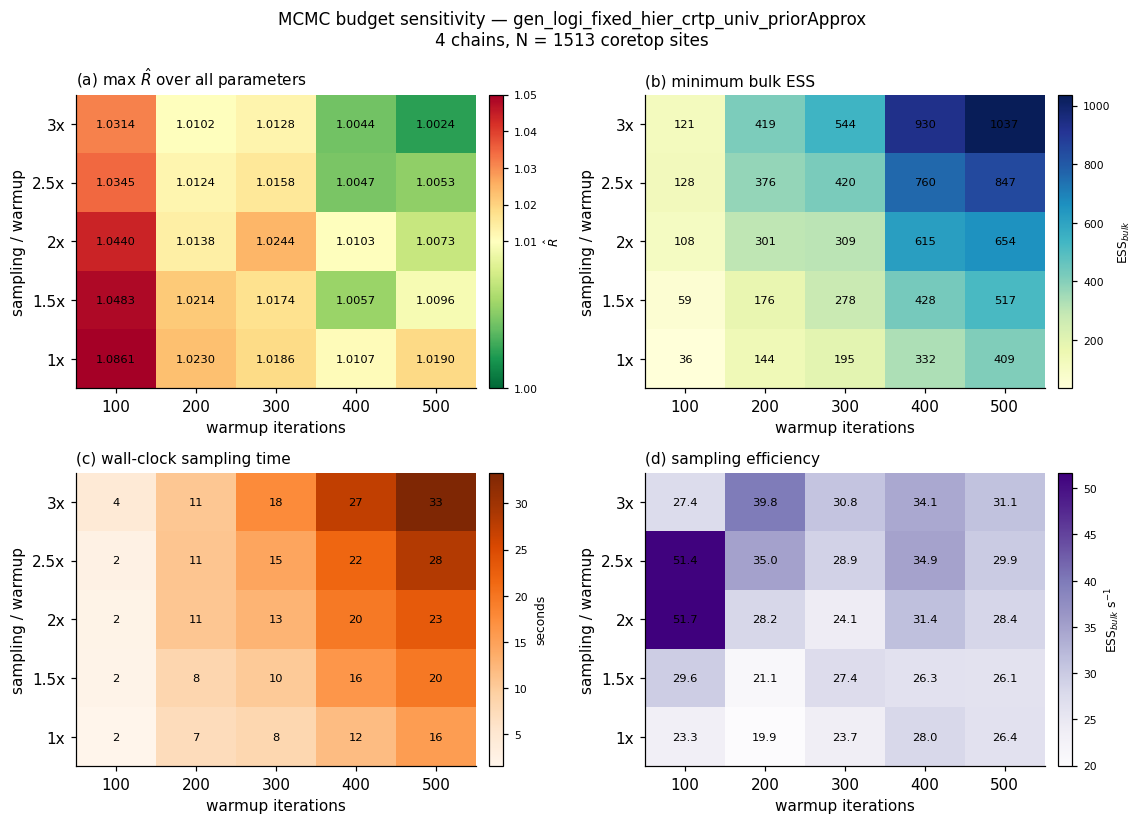

saved -> /home/rrattan/Documents/GitHub/TEXAS/figures/manuscript/revision1/figS_mcmcBudget_heatmaps_eiv.[pdf|png]


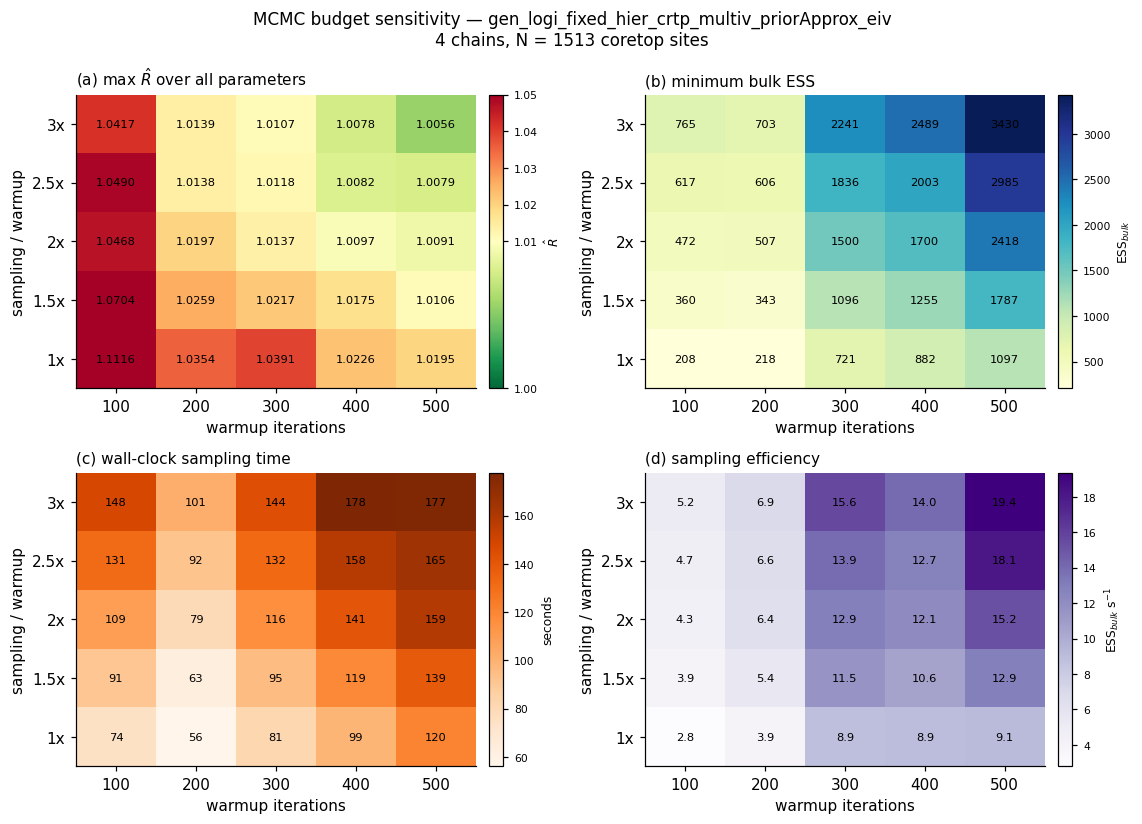

In [12]:
def _pivot(df, model_key, value):
    sub = df[(df["model"] == model_key) & (df.get("status", "ok") == "ok")]
    p = sub.pivot_table(index="multiplier", columns="iter_warmup", values=value)
    return p.reindex(index=sorted(MULTIPLIERS), columns=sorted(WARMUPS))


def _heat(ax, P, title, cbar_label, cmap, norm=None, fmt="{:.3g}",
          annotate=True, vmin=None, vmax=None):
    M = P.values.astype(float)
    im = ax.imshow(M, origin="lower", aspect="auto", cmap=cmap, norm=norm,
                   vmin=vmin, vmax=vmax)
    ax.set_xticks(range(P.shape[1]), [str(c) for c in P.columns])
    ax.set_yticks(range(P.shape[0]), [f"{r:g}x" for r in P.index])
    ax.set_xlabel("warmup iterations")
    ax.set_ylabel("sampling / warmup")
    ax.set_title(title, fontsize=10, loc="left")
    if annotate:
        for i in range(M.shape[0]):
            for j in range(M.shape[1]):
                if np.isfinite(M[i, j]):
                    ax.text(j, i, fmt.format(M[i, j]), ha="center", va="center",
                            fontsize=7.5, color="k")
    cb = ax.figure.colorbar(im, ax=ax, fraction=0.046, pad=0.03)
    cb.set_label(cbar_label, fontsize=8)
    cb.ax.tick_params(labelsize=7)
    return im


for model_key, stan_file in GRID_MODELS:
    if grid_df[grid_df["model"] == model_key].empty:
        continue
    fig, axs = plt.subplots(2, 2, figsize=(10.5, 7.6))

    _heat(axs[0, 0], _pivot(grid_df, model_key, "max_rhat"),
          "(a) max $\\hat{R}$ over all parameters", "$\\hat{R}$",
          cmap="RdYlGn_r", norm=TwoSlopeNorm(vcenter=1.01, vmin=1.0, vmax=1.05),
          fmt="{:.4f}")
    _heat(axs[0, 1], _pivot(grid_df, model_key, "min_ess_bulk"),
          "(b) minimum bulk ESS", "ESS$_{bulk}$", cmap="YlGnBu", fmt="{:.0f}")
    _heat(axs[1, 0], _pivot(grid_df, model_key, "wall_sec"),
          "(c) wall-clock sampling time", "seconds", cmap="Oranges", fmt="{:.0f}")
    _heat(axs[1, 1], _pivot(grid_df, model_key, "ess_bulk_per_sec"),
          "(d) sampling efficiency", "ESS$_{bulk}$ s$^{-1}$",
          cmap="Purples", fmt="{:.1f}")

    fig.suptitle(f"MCMC budget sensitivity — {stan_file}\n"
                 f"{CHAINS} chains, N = {int(grid_df.loc[grid_df['model'] == model_key, 'n_obs'].iloc[0])} coretop sites",
                 fontsize=11)
    fig.tight_layout()
    savefig(fig, f"figS_mcmcBudget_heatmaps_{model_key}")
    plt.show()

### Figure | Where the diagnostics flatten out

saved -> /home/rrattan/Documents/GitHub/TEXAS/figures/manuscript/revision1/figS_mcmcBudget_convergence_curves.[pdf|png]


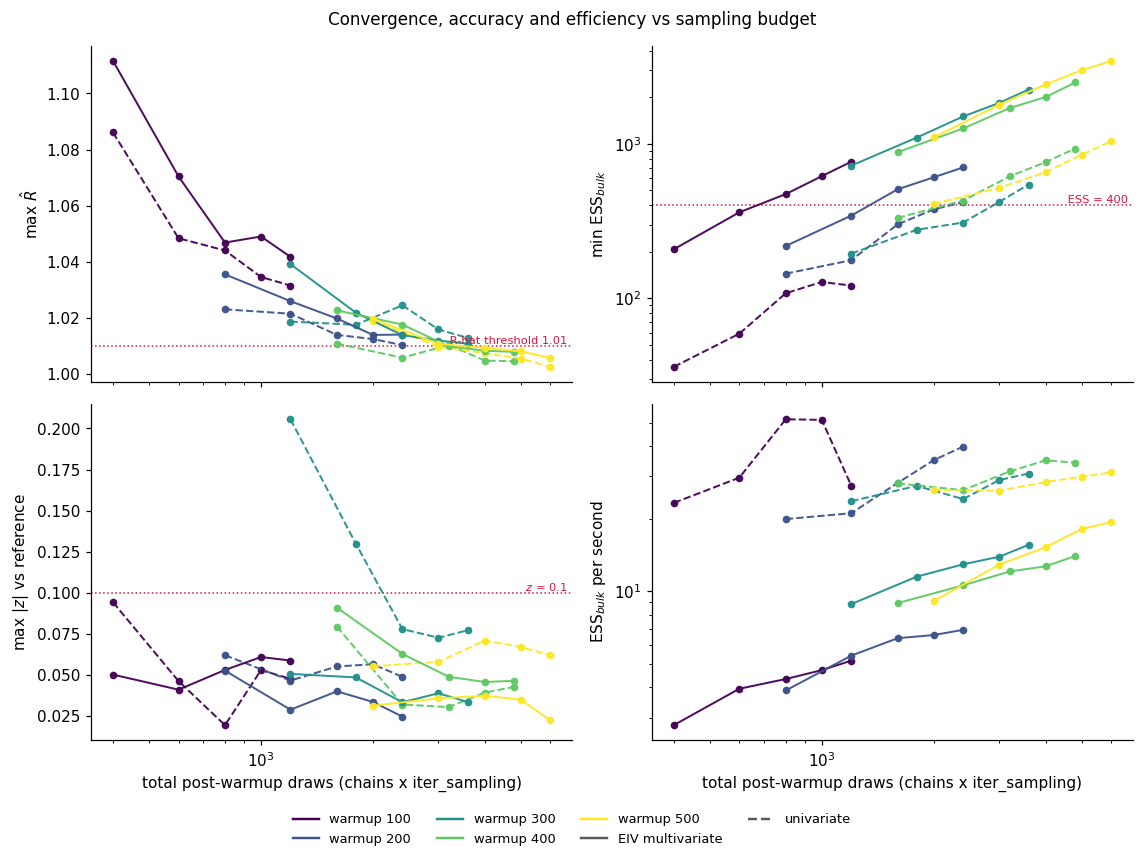

In [13]:
fig, axs = plt.subplots(2, 2, figsize=(10.5, 7.4), sharex=True)
cmap = plt.get_cmap("viridis")
wcolors = {w: cmap(i / max(len(WARMUPS) - 1, 1)) for i, w in enumerate(sorted(WARMUPS))}

MODEL_LINESTYLE = {"univ": "--", "eiv": "-", "bnd": "-."}
MODEL_LABEL = {"univ": "univariate", "eiv": "EIV multivariate (parent)",
               "bnd": "EIV multivariate (boundedT)"}

panels = [
    ("max_rhat",         "max $\\hat{R}$",                 1.01, "R-hat threshold 1.01"),
    ("min_ess_bulk",     "min ESS$_{bulk}$",               400,  "ESS = 400"),
    ("max_z_mean",       "max $|z|$ vs reference",         0.1,  "$z$ = 0.1"),
    ("ess_bulk_per_sec", "ESS$_{bulk}$ per second",        None, None),
]

for ax, (metric, ylabel, thresh, thlabel) in zip(axs.ravel(), panels):
    for model_key, stan_file in GRID_MODELS:
        sub = grid_df[(grid_df["model"] == model_key)
                      & (grid_df.get("status", "ok") == "ok")]
        if sub.empty or metric not in sub:
            continue
        ls = MODEL_LINESTYLE.get(model_key, "-")
        for w in sorted(WARMUPS):
            s = sub[sub["iter_warmup"] == w].sort_values("iter_sampling")
            if s.empty:
                continue
            ax.plot(s["total_draws"], s[metric], ls, marker="o", ms=4,
                    color=wcolors[w], lw=1.3, alpha=0.95)
    if thresh is not None:
        ax.axhline(thresh, color="crimson", lw=1, ls=":", zorder=0)
        ax.text(0.99, thresh, f" {thlabel}", color="crimson", fontsize=7.5,
                ha="right", va="bottom", transform=ax.get_yaxis_transform())
    ax.set_ylabel(ylabel)
    ax.set_xscale("log")
    if metric in ("min_ess_bulk", "ess_bulk_per_sec"):
        ax.set_yscale("log")

for ax in axs[1]:
    ax.set_xlabel("total post-warmup draws (chains x iter_sampling)")

handles = [Line2D([], [], color=wcolors[w], lw=1.6, label=f"warmup {w}")
           for w in sorted(WARMUPS)]
handles += [Line2D([], [], color="0.35", lw=1.6, ls=MODEL_LINESTYLE[k],
                   label=MODEL_LABEL[k])
            for k, _ in GRID_MODELS]
fig.legend(handles=handles, loc="lower center", ncol=4, frameon=False,
           bbox_to_anchor=(0.5, -0.06), fontsize=8.5)
fig.suptitle("Convergence, accuracy and efficiency vs sampling budget", fontsize=11)
fig.tight_layout()
savefig(fig, "figS_mcmcBudget_convergence_curves")
plt.show()

### Figure | Which parameter converges last

Reporting only the maximum R̂ hides *where* the problem is. This panel traces
R̂ per core parameter, which is what tells you whether a short warmup is
failing globally or failing on one badly identified parameter (typically the
EIV process-noise scale `sigma_proxyObs_crtp`).

saved -> /home/rrattan/Documents/GitHub/TEXAS/figures/manuscript/revision1/figS_mcmcBudget_per_parameter_rhat.[pdf|png]


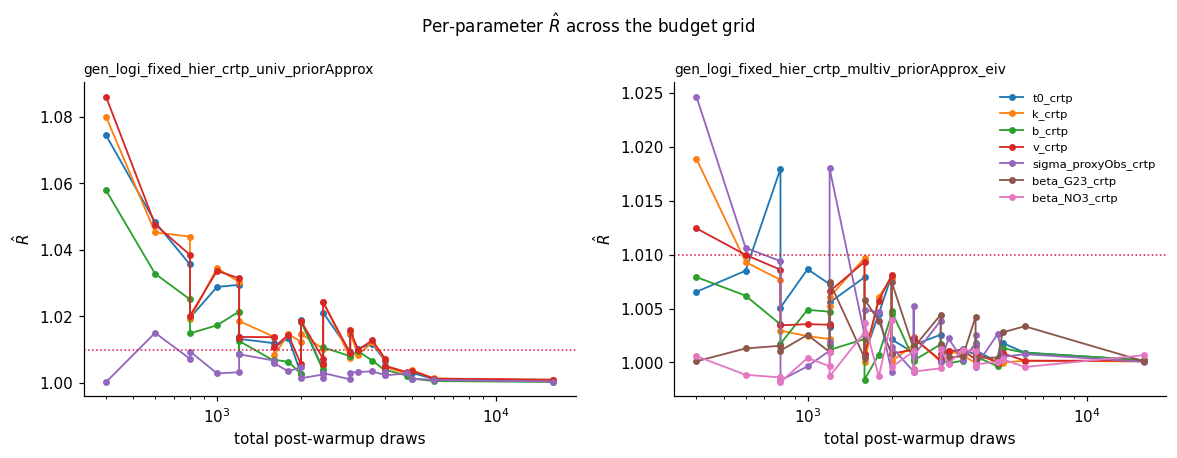

In [14]:
avail = [p for p in CORE_PARAMS if p in set(param_df["param"])]
fig, axs = plt.subplots(1, len(GRID_MODELS), figsize=(5.4 * len(GRID_MODELS), 4.2),
                        squeeze=False)

pcmap = plt.get_cmap("tab10")
for ax, (model_key, stan_file) in zip(axs[0], GRID_MODELS):
    sub = param_df[param_df["model"] == model_key]
    if sub.empty:
        ax.set_visible(False)
        continue
    for i, p in enumerate(avail):
        s = (sub[sub["param"] == p]
             .assign(total=lambda d: CHAINS * d["iter_sampling"])
             .sort_values("total"))
        if s.empty:
            continue
        ax.plot(s["total"], s["rhat"], marker="o", ms=3.5, lw=1.2,
                color=pcmap(i % 10), label=p)
    ax.axhline(1.01, color="crimson", ls=":", lw=1)
    ax.set_xscale("log")
    ax.set_xlabel("total post-warmup draws")
    ax.set_ylabel("$\\hat{R}$")
    ax.set_title(stan_file, fontsize=9, loc="left")

axs[0, -1].legend(fontsize=7.5, frameon=False, loc="upper right", ncol=1)
fig.suptitle("Per-parameter $\\hat{R}$ across the budget grid", fontsize=11)
fig.tight_layout()
savefig(fig, "figS_mcmcBudget_per_parameter_rhat")
plt.show()

### Recommended budget

A cell is **adequate** when all four hold simultaneously:

| criterion | threshold | rationale |
|---|---|---|
| `max_rhat` | < 1.01 | Vehtari et al. (2021) |
| `min_ess_bulk` | ≥ 400 | ≥ 100 per chain at 4 chains |
| `pct_divergent` | = 0 | any divergence biases the posterior |
| `max_z_mean` | ≤ 0.1 | posterior mean within 0.1 SD of the reference |

Among adequate cells the recommendation is the **fastest**, and the speed-up is
quoted against the 1000/1000 incumbent for the same model.

In [15]:
CRITERIA = dict(max_rhat=1.01, min_ess_bulk=400.0, pct_divergent=0.0, max_z_mean=0.1)


def recommend(df, model_key):
    sub = df[(df["model"] == model_key) & (df.get("status", "ok") == "ok")].copy()
    # The reference run is the yardstick, not a candidate.
    sub = sub[~((sub["iter_warmup"] == REF_WARMUP) & (sub["iter_sampling"] == REF_SAMPLING))]
    ok = sub[(sub["max_rhat"] < CRITERIA["max_rhat"])
             & (sub["min_ess_bulk"] >= CRITERIA["min_ess_bulk"])
             & (sub["pct_divergent"] <= CRITERIA["pct_divergent"])
             & (sub["max_z_mean"] <= CRITERIA["max_z_mean"])]
    baseline = sub[(sub["iter_warmup"] == DEFAULT_WARMUP)
                   & (sub["iter_sampling"] == DEFAULT_SAMPLING)]
    base_sec = float(baseline["wall_sec"].iloc[0]) if not baseline.empty else np.nan
    if ok.empty:
        return None, base_sec, sub
    return ok.sort_values("wall_sec").iloc[0], base_sec, sub


recommendations = {}
for model_key, stan_file in GRID_MODELS:
    best, base_sec, sub = recommend(grid_df, model_key)
    print(f"\n=== {stan_file} ===")
    if best is None:
        print("  no cell in the swept grid meets all four criteria.")
        near = sub.sort_values(["max_rhat"]).head(3)
        print("  closest cells by R-hat:")
        print(near[["iter_warmup", "iter_sampling", "max_rhat", "min_ess_bulk",
                    "pct_divergent", "max_z_mean", "wall_sec"]].to_string(index=False))
        continue
    speedup = base_sec / best["wall_sec"] if np.isfinite(base_sec) else np.nan
    recommendations[model_key] = {
        "stan_file": stan_file,
        "iter_warmup": int(best["iter_warmup"]),
        "iter_sampling": int(best["iter_sampling"]),
        "wall_sec": float(best["wall_sec"]),
        "baseline_wall_sec": base_sec,
        "speedup_vs_1000_1000": float(speedup),
        "max_rhat": float(best["max_rhat"]),
        "min_ess_bulk": float(best["min_ess_bulk"]),
        "pct_divergent": float(best["pct_divergent"]),
        "max_z_mean": float(best["max_z_mean"]),
    }
    print(f"  recommended : warmup={int(best['iter_warmup'])}, "
          f"sampling={int(best['iter_sampling'])}")
    print(f"  max R-hat   : {best['max_rhat']:.4f}   "
          f"min ESS_bulk: {best['min_ess_bulk']:.0f}")
    print(f"  divergences : {best['pct_divergent']:.2f}%   "
          f"max |z| vs reference: {best['max_z_mean']:.3f}")
    print(f"  wall time   : {best['wall_sec']:.0f} s vs {base_sec:.0f} s "
          f"at 1000/1000  ->  {speedup:.2f}x faster")

with open(RESULTS_DIR / "recommended_budget.json", "w") as fh:
    json.dump({"criteria": CRITERIA, "quick_run": QUICK,
               "recommendations": recommendations}, fh, indent=2)
print("\nwrote", RESULTS_DIR / "recommended_budget.json")


=== gen_logi_fixed_hier_crtp_univ_priorApprox ===
  recommended : warmup=400, sampling=600
  max R-hat   : 1.0057   min ESS_bulk: 428
  divergences : 0.00%   max |z| vs reference: 0.032
  wall time   : 16 s vs 31 s at 1000/1000  ->  1.92x faster

=== gen_logi_fixed_hier_crtp_multiv_priorApprox_eiv ===
  recommended : warmup=400, sampling=800
  max R-hat   : 1.0097   min ESS_bulk: 1700
  divergences : 0.00%   max |z| vs reference: 0.049
  wall time   : 141 s vs 163 s at 1000/1000  ->  1.16x faster

wrote /home/rrattan/Documents/GitHub/TEXAS/data/revision1/groupA/param_sensitivity/recommended_budget.json


---
# Part 2 | Does the crenarchaeol ring assignment change the calibration?

### The review comment

The Ring Index sums cyclopentane moieties weighted by ring number. Crenarchaeol
and its regioisomer each carry four cyclopentane rings **plus one cyclohexane
ring**, so the weight they receive is a convention:

* **3** — the count used throughout this study;
* **4** — RI₀₋₄ of Zhang et al. (2016), counting the four cyclopentane rings;
* **5** — counting the cyclohexane ring as well.

A reviewer asked whether the calibration and its temperature estimates are an
artefact of the choice. This section refits the **entire two-stage
calibration** — top layer, thermal-only coretop layer, and full EIV
multivariate coretop layer — independently under each convention, on identical
sites, and compares them on curve shape, parameter posteriors, proxy-space fit
and reconstructed-temperature skill.

In [ ]:
def sd_proxyobs_for(cren_rings, n):
    '''Per-site analytical SE of the scaled RI, under the configured convention.'''
    if SD_PROXYOBS_MODE == "scaled_constant":
        val = SD_PROXYOBS_BASE
    elif SD_PROXYOBS_MODE == "ri_constant":
        val = SD_PROXYOBS_BASE * 3.0 / cren_rings
    else:
        raise ValueError(f"unknown SD_PROXYOBS_MODE {SD_PROXYOBS_MODE!r}")
    return np.full(n, val)


# Descriptive comparison of the three definitions before any model is fitted.
desc = []
for label, cfg in PROXIES.items():
    col = cfg["column"]
    for dtype in ["culture", "mesocosm", "coretop"]:
        s = gridded_combined_df.loc[gridded_combined_df["datatype"] == dtype, col].dropna()
        desc.append({"proxy": label, "column": col, "datatype": dtype,
                     "n": len(s), "mean": s.mean(), "sd": s.std(),
                     "min": s.min(), "max": s.max()})
desc_df = pd.DataFrame(desc)
desc_df.to_csv(RESULTS_DIR / "proxy_descriptive_stats.csv", index=False)

pairwise = coretop_df[PROXY_COLS].corr(method="pearson")
print("Coretop Pearson correlation between the three definitions:")
print(pairwise.round(5))
desc_df.round(4)

In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(9.6, 4.1))
labels = list(PROXIES)

ax = axs[0]
for label in labels:
    cfg = PROXIES[label]
    ax.scatter(coretop_df["SST"], coretop_df[cfg["column"]], s=5, alpha=0.35,
               color=cfg["color"], label=f"{label} ({cfg['column']})",
               edgecolors="none")
ax.set_xlabel("SST [$\\degree$C]")
ax.set_ylabel("Scaled Ring Index")
ax.set_title("(a) coretop proxy vs SST", fontsize=10, loc="left")
ax.legend(fontsize=8, frameon=False, markerscale=2.5)

ax = axs[1]
ref = PROXIES[PRODUCTION_PROXY]["column"]
for label in labels:
    if label == PRODUCTION_PROXY:
        continue
    cfg = PROXIES[label]
    d = coretop_df[cfg["column"]] - coretop_df[ref]
    ax.scatter(coretop_df[ref], d, s=5, alpha=0.35, color=cfg["color"],
               edgecolors="none",
               label=f"{label} − {PRODUCTION_PROXY}  "
                     f"(mean {d.mean():+.4f}, sd {d.std():.4f})")
ax.axhline(0, color="k", lw=0.8)
ax.set_xlabel(f"{PRODUCTION_PROXY} ({ref})")
ax.set_ylabel(f"difference from {PRODUCTION_PROXY}")
ax.set_title("(b) offset between conventions", fontsize=10, loc="left")
ax.legend(fontsize=8, frameon=False, markerscale=2.5)

fig.tight_layout()
savefig(fig, "figS_proxyDefinition_data_comparison")
plt.show()

### Refit the two-stage calibration under each convention

Three stages per proxy, in dependency order:

1. `gen_logi_fixed_culmeso` — top layer, culture + mesocosm, culturing T;
2. `gen_logi_fixed_hier_crtp_univ_priorApprox` — thermal-only coretop layer,
   which also supplies the `R2_thermal` the EIV prior is scaled by;
3. `gen_logi_fixed_hier_crtp_multiv_priorApprox_eiv` — full model with G₂/₃ and
   NO₃.

Posteriors go to the normal forward cache via `save_posterior()`, so they are
ordinary TEXAS posteriors and can be loaded by any other notebook.
`SRI03`/stage results already produced by `SI_code2` are reused unless
`FORCE_RERUN` is set.

In [ ]:
def fit_proxy_stack(label, cfg, iter_warmup=None, iter_sampling=None):
    '''Run (or reuse) the three calibration stages for one proxy definition.'''
    col = cfg["column"]
    iter_warmup   = iter_warmup   or PART2_WARMUP
    iter_sampling = iter_sampling or PART2_SAMPLING
    kw = dict(iter_warmup=iter_warmup, iter_sampling=iter_sampling,
              chains=CHAINS, seed=SEED)
    out = {}

    # ── Stage 1: culture + mesocosm ────────────────────────────────────────
    name1 = f"gen_logi_fixed_culmeso_cultureT_{col}"
    try:
        if FORCE_RERUN:
            raise FileNotFoundError
        out["culmeso"] = load_posterior(name1)
        print(f"[{label}] stage 1 cached")
    except Exception:
        cul  = gridded_combined_df[gridded_combined_df["datatype"] == "culture"] \
                   .dropna(subset=[col, "SST"]).reset_index(drop=True)
        meso = gridded_combined_df[gridded_combined_df["datatype"] == "mesocosm"] \
                   .dropna(subset=[col, "SST"]).reset_index(drop=True)
        data = build_fwd_data(
            t_cul=cul["SST"].values,   proxy_cul=cul[col].values,
            t_meso=meso["SST"].values, proxy_meso=meso[col].values,
        )
        post, _ = get_posterior(data=data, stan_file="gen_logi_fixed_culmeso",
                                temptype="cultureT", proxy_name=col, **kw)
        save_posterior(post, filename_suffix="")
        out["culmeso"] = post

    # ── Stage 2: thermal-only coretop ──────────────────────────────────────
    name2 = f"gen_logi_fixed_hier_crtp_univ_priorApprox_{TEMPTYPE}_{col}"
    try:
        if FORCE_RERUN:
            raise FileNotFoundError
        out["univ"] = load_posterior(name2)
        print(f"[{label}] stage 2 cached")
    except Exception:
        reg = coretop_df[["SST", col]].dropna()
        data = build_fwd_data(t_crtp=reg["SST"].values,
                              proxy_crtp=reg[col].values,
                              culmeso_posterior=out["culmeso"])
        post, _ = get_posterior(data=data,
                                stan_file="gen_logi_fixed_hier_crtp_univ_priorApprox",
                                temptype=TEMPTYPE, proxy_name=col, **kw)
        save_posterior(post, filename_suffix="")
        out["univ"] = post

    R2_thermal = float(out["univ"]["R2_full"].mean())

    # ── Stage 3: full multivariate EIV coretop ─────────────────────────────
    name3 = (f"gen_logi_fixed_hier_crtp_multiv_priorApprox_eiv_{TEMPTYPE}"
             f"_gdgt23ratio_no3_{NO3_CUTOFF}_{col}")
    try:
        if FORCE_RERUN:
            raise FileNotFoundError
        out["eiv"] = load_posterior(name3)
        print(f"[{label}] stage 3 cached")
    except Exception:
        reg = coretop_df[["SST", col, "gdgt23ratio", "gdgt23ratio_se",
                          "no3_sf2tc_avg", "thermoNO3_se"]].dropna()
        data = build_fwd_data(
            t_crtp              = reg["SST"].values,
            proxy_crtp          = reg[col].values,
            gdgt23ratio_crtp    = reg["gdgt23ratio"].values,
            sd_gdgt23ratio_crtp = reg["gdgt23ratio_se"].values,
            no3_crtp            = reg["no3_sf2tc_avg"].values,
            sd_no3_crtp         = reg["thermoNO3_se"].values,
            sd_proxyObs         = sd_proxyobs_for(cfg["cren_rings"], len(reg)),
            R2_thermal          = R2_thermal,
            culmeso_posterior   = out["culmeso"],
            no3_cutoff          = NO3_CUTOFF,
        )
        post, _ = get_posterior(
            data=data,
            stan_file="gen_logi_fixed_hier_crtp_multiv_priorApprox_eiv",
            temptype=TEMPTYPE, proxy_name=col, **kw)
        save_posterior(post, filename_suffix="")
        out["eiv"] = post

    out["R2_thermal"] = R2_thermal
    out["n_crtp"] = int(out["eiv"].attrs.get("no3_crtp_len", len(coretop_df)))
    return out


posteriors = {}
for label, cfg in PROXIES.items():
    print(f"\n{'=' * 62}\n {label}  ({cfg['column']}, crenarchaeol = "
          f"{cfg['cren_rings']} rings)\n{'=' * 62}")
    posteriors[label] = fit_proxy_stack(label, cfg)

# All three conventions must be fitted to the *same* sites, or any difference
# could be a sampling artefact rather than a convention effect.
ns = {k: v["n_crtp"] for k, v in posteriors.items()}
print("\ncoretop N per proxy:", ns)
assert len(set(ns.values())) == 1, f"proxies fitted on different site counts: {ns}"

### Parameter and goodness-of-fit comparison

In [ ]:
SUMMARY_PARAMS = ["t0_crtp", "k_crtp", "b_crtp", "v_crtp",
                  "sigma_proxyObs_crtp", "beta_G23_crtp", "beta_NO3_crtp"]


def _stat(ds, name):
    if name not in ds:
        return None
    v = np.asarray(ds[name].values, dtype=float).ravel()
    return dict(mean=v.mean(), sd=v.std(ddof=1),
                q025=np.percentile(v, 2.5), q160=np.percentile(v, 16),
                q500=np.percentile(v, 50), q840=np.percentile(v, 84),
                q975=np.percentile(v, 97.5))


rows = []
for label in PROXIES:
    ds = posteriors[label]["eiv"]
    for p in SUMMARY_PARAMS:
        st = _stat(ds, p)
        if st:
            rows.append({"proxy": label, "param": p, **st})
param_compare = pd.DataFrame(rows)
param_compare.to_csv(RESULTS_DIR / "proxy_parameter_comparison.csv", index=False)

fit_rows = []
for label, cfg in PROXIES.items():
    ds = posteriors[label]["eiv"]
    fit_rows.append({
        "proxy": label,
        "column": cfg["column"],
        "cren_rings": cfg["cren_rings"],
        "n_crtp": posteriors[label]["n_crtp"],
        "R2_thermal": posteriors[label]["R2_thermal"],
        "R2_full": float(ds["R2_full"].mean()) if "R2_full" in ds else np.nan,
        "bayesR2_full": float(ds["bayesR2_full"].mean()) if "bayesR2_full" in ds else np.nan,
        "RMSE_proxy": float(ds["RMSE_full"].mean()) if "RMSE_full" in ds else np.nan,
        "max_rhat": ds.attrs.get("stan_diag_max_rhat", np.nan),
        "min_ess_bulk": ds.attrs.get("stan_diag_min_ess_bulk", np.nan),
        "pct_divergent": ds.attrs.get("stan_diag_pct_divergent", np.nan),
        "overall": ds.attrs.get("stan_diag_overall_status", ""),
    })
fit_df = pd.DataFrame(fit_rows)
fit_df.round(5)

### Figure | Calibration curves under the three conventions

In [ ]:
XX = np.linspace(-2, 40, 200)
g23_med = float(np.nanmedian(coretop_df["gdgt23ratio"]))
no3_med = float(np.nanmedian(coretop_df["no3_sf2tc_avg"]))

fig, axs = plt.subplots(1, 2, figsize=(10.4, 4.4))

# (a) top layer — culture + mesocosm
ax = axs[0]
culmeso_df = (gridded_combined_df[gridded_combined_df["datatype"].isin(["culture", "mesocosm"])]
              .dropna(subset=["SST"]))
for label, cfg in PROXIES.items():
    ens = generate_ensemble_auto(post_ds=posteriors[label]["culmeso"],
                                 x_vals=XX, percentiles=[2.5, 50, 97.5])
    ax.plot(XX, ens["p50"], color=cfg["color"], lw=1.8, label=label)
    ax.fill_between(XX, ens["p2.5"], ens["p97.5"], color=cfg["color"], alpha=0.15,
                    lw=0)
    ax.scatter(culmeso_df["SST"], culmeso_df[cfg["column"]], s=14,
               color=cfg["color"], alpha=0.55, edgecolors="k", linewidths=0.3)
ax.set_xlabel("Culturing / mesocosm T [$\\degree$C]")
ax.set_ylabel("Scaled Ring Index")
ax.set_title("(a) top layer: culture + mesocosm", fontsize=10, loc="left")
ax.legend(fontsize=8.5, frameon=False)

# (b) bottom layer — coretop, EIV multivariate, at median G23 and NO3
ax = axs[1]
for label, cfg in PROXIES.items():
    ens = generate_ensemble_auto(
        post_ds=posteriors[label]["eiv"], x_vals=XX,
        gdgt23ratio=np.full_like(XX, g23_med),
        no3=np.full_like(XX, no3_med),
        no3_cutoff=NO3_CUTOFF, percentiles=[2.5, 50, 97.5])
    ax.plot(XX, ens["p50"], color=cfg["color"], lw=1.8, label=label)
    ax.fill_between(XX, ens["p2.5"], ens["p97.5"], color=cfg["color"], alpha=0.15,
                    lw=0)
    ax.scatter(coretop_df["SST"], coretop_df[cfg["column"]], s=3,
               color=cfg["color"], alpha=0.18, edgecolors="none")
ax.set_xlabel("SST [$\\degree$C]")
ax.set_ylabel("Scaled Ring Index")
ax.set_title(f"(b) bottom layer: coretop EIV, at median G$_{{2/3}}$ = {g23_med:.2f}, "
             f"NO$_3^-$ = {no3_med:.2f}", fontsize=10, loc="left")
ax.legend(fontsize=8.5, frameon=False)

fig.suptitle("Calibration curves under three crenarchaeol ring conventions", fontsize=11)
fig.tight_layout()
savefig(fig, "figS_proxyDefinition_calibration_curves")
plt.show()

### Figure | Posterior parameters and fit statistics

In [ ]:
present = [p for p in SUMMARY_PARAMS if p in set(param_compare["param"])]
ncol = len(present)
fig, axs = plt.subplots(1, ncol + 1, figsize=(1.65 * (ncol + 1) + 2.2, 3.6))

labels = list(PROXIES)
ypos = {lab: i for i, lab in enumerate(labels[::-1])}

for ax, p in zip(axs, present):
    for lab in labels:
        r = param_compare[(param_compare["proxy"] == lab)
                          & (param_compare["param"] == p)]
        if r.empty:
            continue
        r = r.iloc[0]
        y = ypos[lab]
        c = PROXIES[lab]["color"]
        ax.plot([r["q025"], r["q975"]], [y, y], color=c, lw=1.2, alpha=0.6)
        ax.plot([r["q160"], r["q840"]], [y, y], color=c, lw=3.2)
        ax.plot([r["q500"]], [y], "o", color=c, ms=5, mec="k", mew=0.4)
    ax.set_yticks(list(ypos.values()), list(ypos.keys()))
    ax.set_title(p.replace("_crtp", ""), fontsize=9)
    ax.tick_params(labelsize=8)
    ax.margins(y=0.35)

ax = axs[-1]
w = 0.35
for i, lab in enumerate(labels):
    row = fit_df[fit_df["proxy"] == lab].iloc[0]
    ax.barh(ypos[lab] + w / 2, row["R2_full"], height=w,
            color=PROXIES[lab]["color"], alpha=0.9)
    ax.text(row["R2_full"], ypos[lab] + w / 2, f"  {row['R2_full']:.3f}",
            va="center", fontsize=7.5)
ax.set_yticks(list(ypos.values()), list(ypos.keys()))
ax.set_title("$R^2$ (full model)", fontsize=9)
ax.set_xlim(0, max(1.0, fit_df["R2_full"].max() * 1.25))
ax.tick_params(labelsize=8)
ax.margins(y=0.35)

fig.suptitle("Coretop EIV posteriors: median, 68% and 95% CI", fontsize=11)
fig.tight_layout()
savefig(fig, "figS_proxyDefinition_posterior_params")
plt.show()

### Reconstructed-temperature skill

Proxy-space $R^2$ is not what a reviewer cares about — the question is whether
the reconstructed temperature moves. Each coretop site is inverted through its
own calibration with the posterior-median parameters, and the residual against
observed SST is compared across conventions.

This is the deterministic point inverse (`inverse_generalized_logistic_
fixed_upper_multivariate`), not the full Bayesian marginalisation of
`predict_T_from_proxyObs`. That is deliberate: the comparison is *between*
conventions on identical sites, so the shared marginalisation machinery would
cancel, and the point inverse keeps this section to seconds rather than hours.
Absolute uncertainties quoted in the manuscript still come from the Bayesian
path.

In [ ]:
def median_params(ds):
    out = {}
    for p in ["t0_crtp", "k_crtp", "b_crtp", "v_crtp",
              "beta_G23_crtp", "beta_NO3_crtp"]:
        if p in ds:
            out[p.replace("_crtp", "")] = float(np.median(np.asarray(ds[p].values)))
    return out


resid = {}
skill_rows = []
for label, cfg in PROXIES.items():
    mp = median_params(posteriors[label]["eiv"])
    t_hat = inverse_generalized_logistic_fixed_upper_multivariate(
        y=coretop_df[cfg["column"]].values,
        t0=mp["t0"], b=mp["b"], k=mp["k"], v=mp.get("v"),
        beta_G23=mp.get("beta_G23"), gdgt23ratio=coretop_df["gdgt23ratio"].values,
        beta_NO3=mp.get("beta_NO3"), no3=coretop_df["no3_sf2tc_avg"].values,
        no3_cutoff=NO3_CUTOFF,
    )
    r = np.asarray(t_hat, dtype=float) - coretop_df["SST"].values
    resid[label] = r
    ok = np.isfinite(r)
    skill_rows.append({
        "proxy": label,
        "n_invertible": int(ok.sum()),
        "n_total": len(r),
        "pct_uninvertible": 100 * (1 - ok.mean()),
        "bias_degC": float(np.nanmean(r)),
        "RMSE_degC": float(np.sqrt(np.nanmean(r[ok] ** 2))),
        "MAE_degC": float(np.nanmean(np.abs(r[ok]))),
        "p16_degC": float(np.nanpercentile(r[ok], 16)),
        "p84_degC": float(np.nanpercentile(r[ok], 84)),
    })

skill_df = pd.DataFrame(skill_rows)
skill_df.to_csv(RESULTS_DIR / "proxy_temperature_skill.csv", index=False)
skill_df.round(3)

In [ ]:
fig, axs = plt.subplots(1, 3, figsize=(12.4, 3.9))

ax = axs[0]
for label, cfg in PROXIES.items():
    ax.scatter(coretop_df["SST"], resid[label], s=4, alpha=0.3,
               color=cfg["color"], edgecolors="none", label=label)
ax.axhline(0, color="k", lw=0.8)
ax.set_xlabel("observed SST [$\\degree$C]")
ax.set_ylabel("reconstructed − observed [$\\degree$C]")
ax.set_title("(a) coretop temperature residuals", fontsize=10, loc="left")
ax.legend(fontsize=8, frameon=False, markerscale=3)

ax = axs[1]
bins = np.linspace(-15, 15, 61)
for label, cfg in PROXIES.items():
    r = resid[label]
    ax.hist(r[np.isfinite(r)], bins=bins, histtype="step", lw=1.6,
            color=cfg["color"], density=True, label=label)
ax.axvline(0, color="k", lw=0.8)
ax.set_xlabel("residual [$\\degree$C]")
ax.set_ylabel("density")
ax.set_title("(b) residual distribution", fontsize=10, loc="left")
ax.legend(fontsize=8, frameon=False)

ax = axs[2]
ref = resid[PRODUCTION_PROXY]
for label, cfg in PROXIES.items():
    if label == PRODUCTION_PROXY:
        continue
    d = resid[label] - ref
    ax.scatter(coretop_df["SST"], d, s=4, alpha=0.35, color=cfg["color"],
               edgecolors="none",
               label=f"{label} − {PRODUCTION_PROXY}  "
                     f"(mean {np.nanmean(d):+.2f}, sd {np.nanstd(d):.2f} $\\degree$C)")
ax.axhline(0, color="k", lw=0.8)
ax.set_xlabel("observed SST [$\\degree$C]")
ax.set_ylabel(f"$\\Delta$T vs {PRODUCTION_PROXY} [$\\degree$C]")
ax.set_title("(c) per-site temperature difference", fontsize=10, loc="left")
ax.legend(fontsize=7.5, frameon=False, markerscale=3)

fig.suptitle("Reconstructed coretop temperature under three ring conventions",
             fontsize=11)
fig.tight_layout()
savefig(fig, "figS_proxyDefinition_temperature_residuals")
plt.show()

### Combined results table

In [ ]:
combined = fit_df.merge(skill_df, on="proxy")
combined.to_csv(RESULTS_DIR / "proxy_definition_summary.csv", index=False)

show = ["proxy", "column", "cren_rings", "n_crtp", "R2_full", "RMSE_proxy",
        "RMSE_degC", "bias_degC", "pct_uninvertible", "max_rhat", "overall"]
print("wrote", RESULTS_DIR / "proxy_definition_summary.csv")
combined[show].round(4)

### Summary for the response to reviewers

Run the cell below **after** both parts have completed; it prints the numbers
in the form they are quoted in the response letter, rather than asking anyone
to read them off the figures.

In [ ]:
print("=" * 70)
print("PART 1 — sampler budget")
print("=" * 70)
if not recommendations:
    print("No recommendation: no swept cell met all four criteria.")
for k, r in recommendations.items():
    print(f"\n{r['stan_file']}")
    print(f"  recommended warmup/sampling : {r['iter_warmup']}/{r['iter_sampling']}")
    print(f"  max R-hat                   : {r['max_rhat']:.4f}  (threshold 1.01)")
    print(f"  min bulk ESS                : {r['min_ess_bulk']:.0f}  (threshold 400)")
    print(f"  divergent transitions       : {r['pct_divergent']:.2f}%")
    print(f"  posterior mean drift        : max |z| = {r['max_z_mean']:.3f} SD "
          f"vs the {REF_WARMUP}/{REF_SAMPLING} reference")
    print(f"  wall time                   : {r['wall_sec']:.0f} s vs "
          f"{r['baseline_wall_sec']:.0f} s at 1000/1000 "
          f"({r['speedup_vs_1000_1000']:.2f}x faster)")

print("\n" + "=" * 70)
print("PART 2 — crenarchaeol ring convention")
print("=" * 70)
base = combined[combined["proxy"] == PRODUCTION_PROXY].iloc[0]
for _, r in combined.iterrows():
    tag = "  (production)" if r["proxy"] == PRODUCTION_PROXY else ""
    print(f"\n{r['proxy']} — cren = {r['cren_rings']} rings{tag}")
    print(f"  R2 (proxy space) : {r['R2_full']:.4f}   "
          f"RMSE (proxy) : {r['RMSE_proxy']:.4f}")
    print(f"  RMSE (T)         : {r['RMSE_degC']:.2f} degC   "
          f"bias : {r['bias_degC']:+.2f} degC")
    if r["proxy"] != PRODUCTION_PROXY:
        d = resid[r["proxy"]] - resid[PRODUCTION_PROXY]
        print(f"  vs {PRODUCTION_PROXY}: dR2 = {r['R2_full'] - base['R2_full']:+.4f}, "
              f"dRMSE(T) = {r['RMSE_degC'] - base['RMSE_degC']:+.2f} degC, "
              f"per-site dT = {np.nanmean(d):+.2f} +/- {np.nanstd(d):.2f} degC")

print(f"\nCoretop correlation between conventions (Pearson):")
print(pairwise.round(5).to_string())
if QUICK:
    print("\n*** QUICK=True — these numbers are a smoke test, not results. ***")

---
## Notes and caveats

* **R̂ is compared at a fixed chain count.** R̂ is a between-chain statistic, so
  the grid holds `chains = 4` throughout. A budget adequate at 4 chains is not
  automatically adequate at 2.
* **Wall time excludes compilation.** Stan binaries are compiled once per
  session and cached; the timings measure sampling only, which is what scales
  with the training set.
* **The recommendation is machine-relative in seconds, not in iterations.** The
  iteration counts transfer between machines; the wall times and the speed-up
  factor do not.
* **Part 1 sweeps SRI03 only.** The budget question is about data size and model
  geometry, not the proxy definition; Part 2 confirms the three conventions
  produce fits of nearly identical geometry, so the budget carries over.
* **The point inverse in Part 2 is a comparison tool.** Manuscript
  uncertainties come from `predict_T_from_proxyObs`, which marginalises over the
  whole forward posterior.